# EDA DATA

In [2]:
# Imports
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
import yaml

sns.set_theme(style="whitegrid")
%matplotlib inline

DATA_DIR = Path("../data")   # racine du dataset (relatif à notebooks/)
CONFIG_PATH = Path("../data/smoke.yaml")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


## 1.chargement de config et inventaire de data

In [3]:
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

class_names = config["names"]
print(f"Classes ({config['nc']}) :", class_names)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def list_split(split):
    img_dir = DATA_DIR / "images" / split
    lbl_dir = DATA_DIR / "labels" / split
    if not img_dir.exists():
        return [], lbl_dir
    images = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS])
    return images, lbl_dir

splits = {}
for split in ["train", "val", "test"]:
    images, lbl_dir = list_split(split)
    splits[split] = {"images": images, "labels_dir": lbl_dir}
    print(f"{split:6s}: {len(images):6d} images")

Classes (2) : {0: 'smoke', 1: 'fire'}
train :  17221 images
val   :   2152 images
test  :   2154 images


## 2.charge les annotation dans les dataframe

In [4]:
def load_annotations(split_name, images, labels_dir):
    rows = []
    for img_path in images:
        label_path = labels_dir / f"{img_path.stem}.txt"
        if not label_path.exists():
            continue
        with open(label_path, "r") as f:
            lines = [l.strip() for l in f if l.strip()]
        for line in lines:
            parts = line.split()
            if len(parts) != 5:
                continue
            cls_id, xc, yc, w, h = parts
            rows.append({
                "split": split_name,
                "image": img_path.name,
                "image_path": str(img_path),
                "class_id": int(cls_id),
                "class_name": class_names[int(cls_id)],
                "x_center": float(xc),
                "y_center": float(yc),
                "width": float(w),
                "height": float(h),
            })
    return rows

all_rows = []
for split_name, d in splits.items():
    all_rows.extend(load_annotations(split_name, d["images"], d["labels_dir"]))

df = pd.DataFrame(all_rows)
df["area_norm"] = df["width"] * df["height"]          # aire normalisée (0-1)
df["aspect_ratio"] = df["width"] / df["height"]

print(f"Total bounding boxes : {len(df)}")
df.head()


Total bounding boxes : 26557


,split,image,image_path,class_id,class_name,x_center,y_center,width,height,area_norm,aspect_ratio
0,train,AoF00001.jpg,..\data\images\train\AoF00001.jpg,1,fire,0.216228,0.739130,0.136899,0.150502,0.020604,0.909620
1,train,AoF00002.jpg,..\data\images\train\AoF00002.jpg,0,smoke,0.767249,0.288907,0.036799,0.054636,0.002011,0.673525
2,train,AoF01030.jpg,..\data\images\train\AoF01030.jpg,0,smoke,0.946875,0.186806,0.057813,0.095833,0.005540,0.603261
3,train,AoF01166.jpg,..\data\images\train\AoF01166.jpg,0,smoke,0.514453,0.352778,0.897656,0.525000,0.471270,1.709821
4,train,AoF02119.jpg,..\data\images\train\AoF02119.jpg,1,fire,0.427344,0.047917,0.353125,0.095833,0.033841,3.684783


## 3. Répartition des classes par split

class_name,fire,smoke
split,,
test,1489,1229
train,11761,9460
val,1442,1176


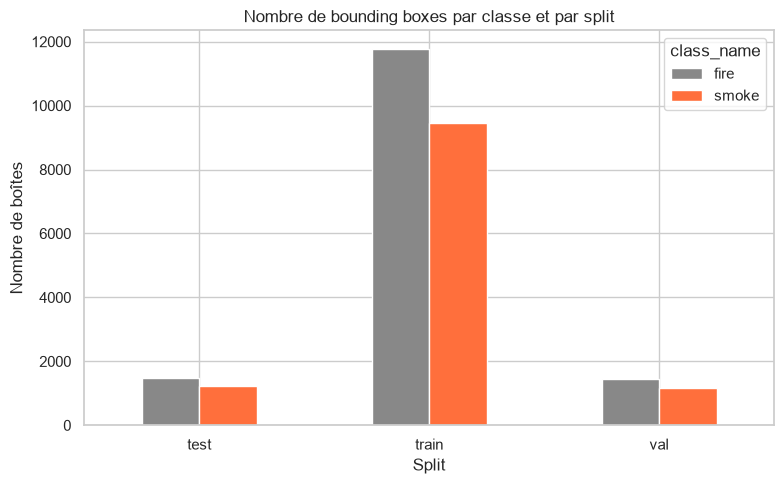

In [5]:
class_counts = df.groupby(["split", "class_name"]).size().unstack(fill_value=0)
display(class_counts)

fig, ax = plt.subplots(figsize=(8, 5))
class_counts.plot(kind="bar", ax=ax, color=["#888888", "#ff6f3c"])
ax.set_title("Nombre de bounding boxes par classe et par split")
ax.set_ylabel("Nombre de boîtes")
ax.set_xlabel("Split")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


si un fort déséquilibre apparaît entre `smoke` et `fire`
(ou entre splits), envisager :
- `class_weights` custom pendant l'entraînement, ou
- un ré-échantillonnage ciblé (sur-représenter la classe minoritaire dans le split train)

## 4. Distribution de la taille des objets (aire normalisée)

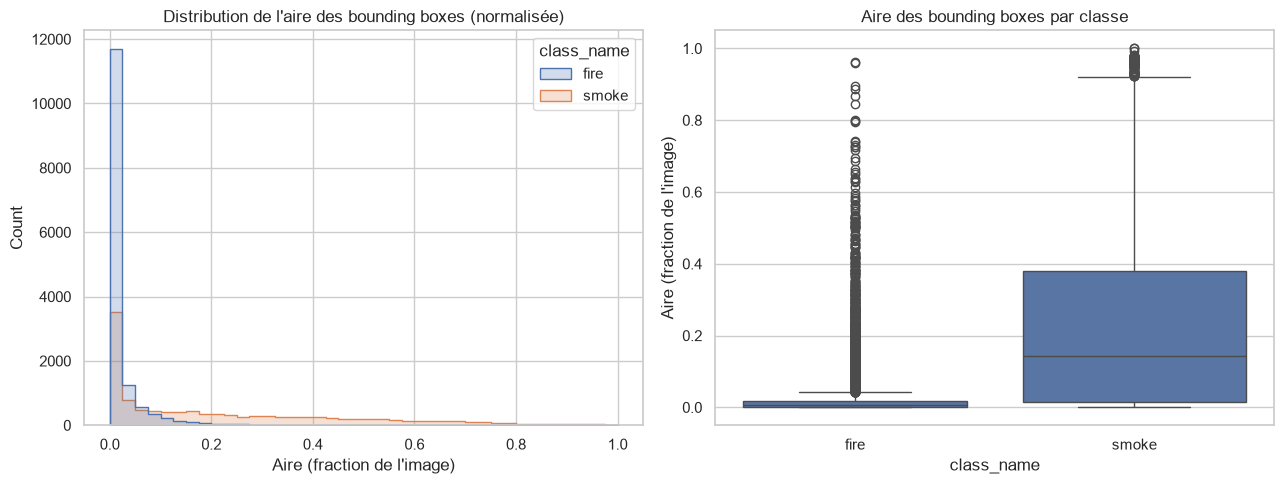

Proportion d'objets 'petits' (aire < 2% de l'image) : 54.4%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=df, x="area_norm", hue="class_name", bins=40, ax=axes[0], element="step")
axes[0].set_title("Distribution de l'aire des bounding boxes (normalisée)")
axes[0].set_xlabel("Aire (fraction de l'image)")

sns.boxplot(data=df, x="class_name", y="area_norm", ax=axes[1])
axes[1].set_title("Aire des bounding boxes par classe")
axes[1].set_ylabel("Aire (fraction de l'image)")

plt.tight_layout()
plt.show()

small_ratio = (df["area_norm"] < 0.02).mean()
print(f"Proportion d'objets 'petits' (aire < 2% de l'image) : {small_ratio:.1%}")


## 5. Distribution du ratio d'aspect (largeur / hauteur)

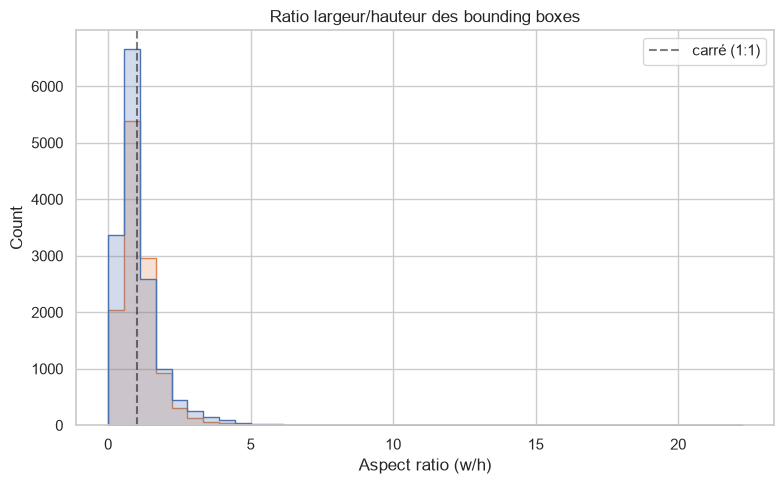

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x="aspect_ratio", hue="class_name", bins=40, ax=ax, element="step")
ax.set_title("Ratio largeur/hauteur des bounding boxes")
ax.set_xlabel("Aspect ratio (w/h)")
ax.axvline(1.0, color="black", linestyle="--", alpha=0.5, label="carré (1:1)")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Heatmap de position des objets dans l'image

Utile pour repérer un biais de cadrage (ex: la fumée est-elle toujours filmée
dans le tiers supérieur de l'image ? Cela pourrait biaiser le modèle si les
caméras de déploiement réel ont un cadrage différent).

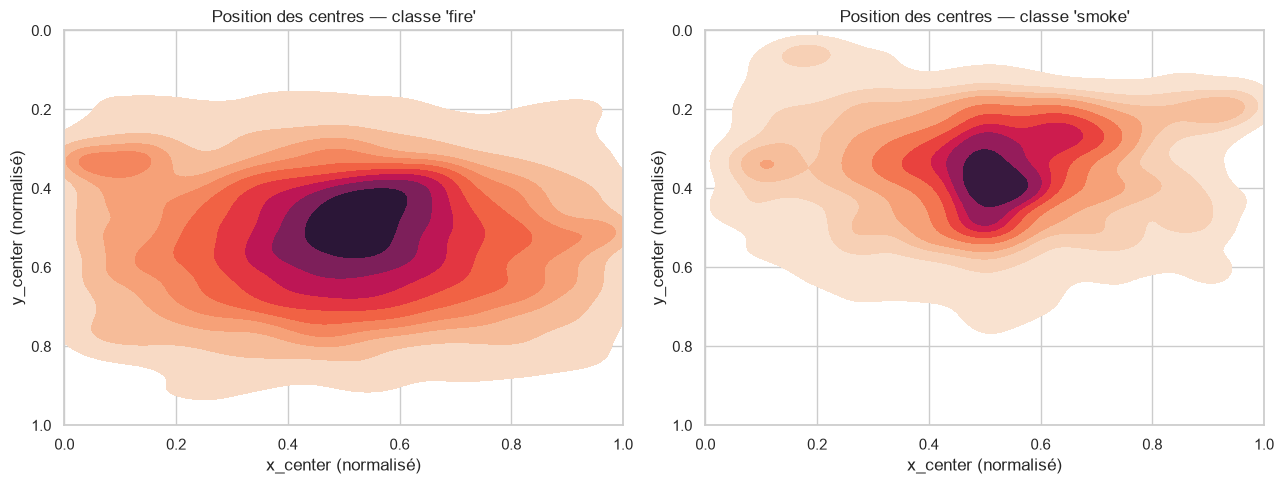

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cls in zip(axes, df["class_name"].unique()):
    sub = df[df["class_name"] == cls]
    sns.kdeplot(x=sub["x_center"], y=sub["y_center"], fill=True, cmap="rocket_r", ax=ax, thresh=0.05)
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)  # inverser l'axe y : (0,0) = coin haut-gauche en image
    ax.set_title(f"Position des centres — classe '{cls}'")
    ax.set_xlabel("x_center (normalisé)")
    ax.set_ylabel("y_center (normalisé)")

plt.tight_layout()
plt.show()


## 7. Dimensions des images (homogénéité du dataset)

             width       height
count   300.000000   300.000000
mean    965.243333   574.810000
std     357.022700   180.192448
min     198.000000   155.000000
25%     640.000000   360.000000
50%    1024.000000   622.000000
75%    1280.000000   720.000000
max    1920.000000  1200.000000


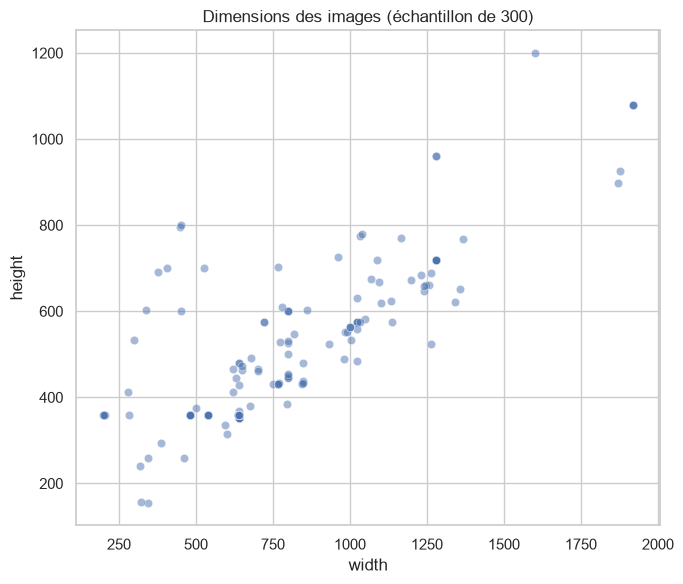

In [10]:
sample_size = min(300, len(df["image_path"].unique()))
sample_paths = random.sample(list(df["image_path"].unique()), sample_size)

dims = []
for p in sample_paths:
    img = cv2.imread(p)
    if img is not None:
        h, w = img.shape[:2]
        dims.append({"width": w, "height": h})

dims_df = pd.DataFrame(dims)
print(dims_df.describe())

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=dims_df, x="width", y="height", alpha=0.5, ax=ax)
ax.set_title(f"Dimensions des images (échantillon de {sample_size})")
plt.tight_layout()
plt.show()


## 8. Visualisation d'échantillons avec bounding boxes

Vérification qualitative rapide : les annotations sont-elles cohérentes ?

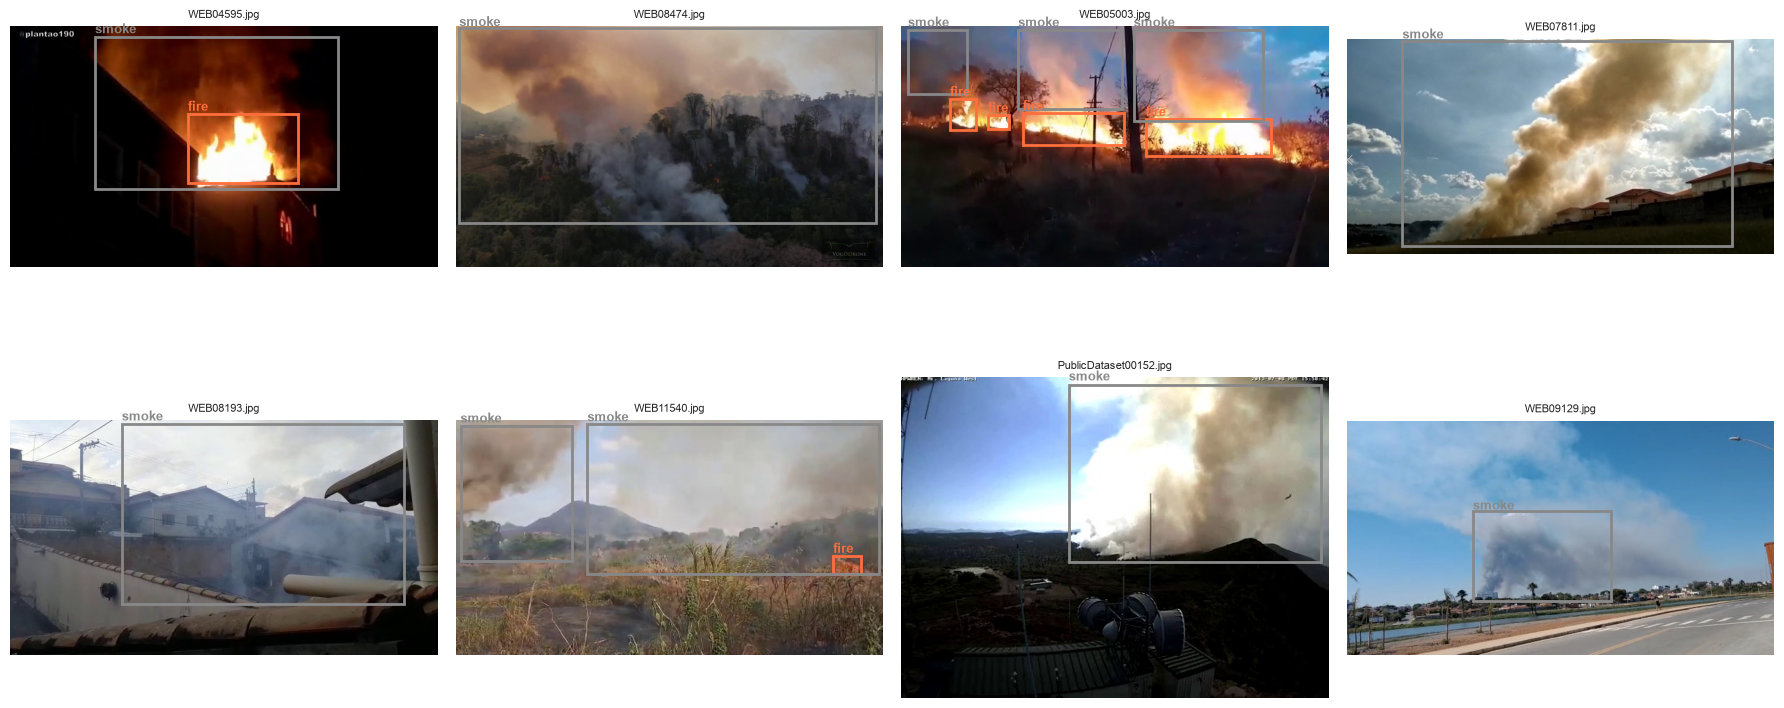

In [11]:
COLORS = {"smoke": (136, 136, 136), "fire": (255, 111, 60)}  # RGB pour matplotlib

def plot_sample(image_path, split, n_cols=4, ax=None):
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    boxes = df[df["image_path"] == image_path]

    ax.imshow(img)
    for _, row in boxes.iterrows():
        x_c, y_c, bw, bh = row["x_center"] * w, row["y_center"] * h, row["width"] * w, row["height"] * h
        x1, y1 = x_c - bw / 2, y_c - bh / 2
        color = np.array(COLORS.get(row["class_name"], (0, 255, 0))) / 255
        rect = patches.Rectangle((x1, y1), bw, bh, linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, row["class_name"], color=color, fontsize=9, weight="bold")
    ax.set_title(Path(image_path).name, fontsize=8)
    ax.axis("off")


sample_images = random.sample(list(df["image_path"].unique()), 8)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for img_path, ax in zip(sample_images, axes.flatten()):
    plot_sample(img_path, split=None, ax=ax)
plt.tight_layout()
plt.show()


## 9. Test rapide d'un modèle pré-entraîné (zero-shot, avant fine-tuning)

Sert de point de comparaison "avant/après entraînement" : un YOLO pré-entraîné sur COCO
ne connaît pas les classes `smoke`/`fire`, mais peut détecter des objets génériques
(personnes, véhicules) utiles pour évaluer le bruit de fond de la scène.

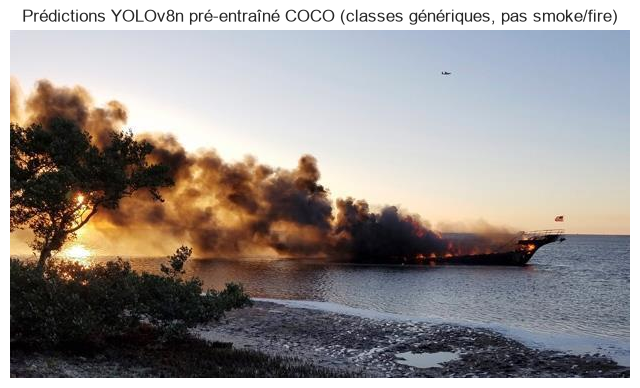

In [16]:
from ultralytics import YOLO

# Modèle nano pré-entraîné COCO, seulement pour prototypage rapide (pas le modèle final)
yolo_coco = YOLO("yolov8n.pt")

sample_path = random.choice(list(df["image_path"].unique()))
result = yolo_coco.predict(sample_path, conf=0.25, verbose=False)[0]

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(result.plot()[..., ::-1])  # BGR -> RGB
ax.set_title("Prédictions YOLOv8n pré-entraîné COCO (classes génériques, pas smoke/fire)")
ax.axis("off")
plt.show()
